In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.io import read_image
from torchvision.models import resnet18
from torchvision.transforms.functional import to_tensor

import warnings
warnings.simplefilter('ignore')

In [ ]:
from PIL import Image
from tqdm import trange

In [ ]:
TRAIN_IMAGES_FODLER = '/kaggle/input/aaa-ml-comp/numbers_reading_train/'  # данные обучающей выборки
TEST_IMAGES_FODLER = '/kaggle/input/aaa-ml-comp/numbers_reading_test'  # данные тестовой выборки
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

TRAIN_FILE = '/kaggle/input/aaa-ml-comp/train_images.csv'  # данные с разметкой и названиеми файлов
TEST_FILE = '/kaggle/input/aaa-ml-comp/test_images.csv'  # данные с названиеми тестовых картинок файлов


MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

In [ ]:
train_data = pd.read_csv(TRAIN_FILE)
train_data.head()

,image,number
0,4445.jpg,а729на126
1,5688.jpg,а365мт177
2,11820.jpg,х901рр123
3,10986.jpg,м215ех178
4,11192.jpg,к969то161


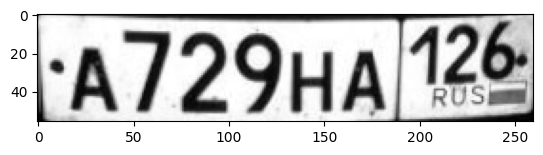

In [ ]:
im = plt.imread(os.path.join(TRAIN_IMAGES_FODLER, '4445.jpg'))
plt.imshow(im, cmap='gray');

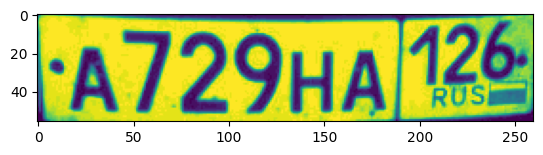

In [ ]:
def read_numpy_gray(im):
    im = torch.from_numpy(im)
    im = im.unsqueeze(0)
    im = im.repeat(3, 1, 1)
    im = im.permute(1, 2, 0)
    return im.numpy()

plt.imshow(read_numpy_gray(im)[..., 0] // 10);

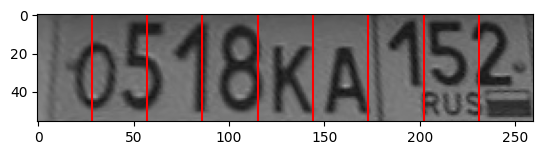

In [ ]:
im = plt.imread(os.path.join(TRAIN_IMAGES_FODLER, '10008.jpg'))
plt.imshow(read_numpy_gray(im))

for i in range(1, 9):
    plt.plot([i * im.shape[1] // 9, i * im.shape[1] // 9], [0, 55], 'r');

Реализуем функцию, позволяющую отрисовать несколько картинок с разметкой в title:

In [ ]:
def plot_samples(images, labels, nrows=3, ncols=3):

    f, axes = plt.subplots(nrows=nrows, ncols=nrows,)
    f.set_figheight(9)
    f.set_figwidth(9)

    for im_file, num, ax in zip(images, labels, axes.flatten()):
        im_path = os.path.join(TRAIN_IMAGES_FODLER, im_file)
        im = plt.imread(im_path)
        ax.imshow(im, cmap='gray')
        ax.set_title(num)
        ax.axis('off')

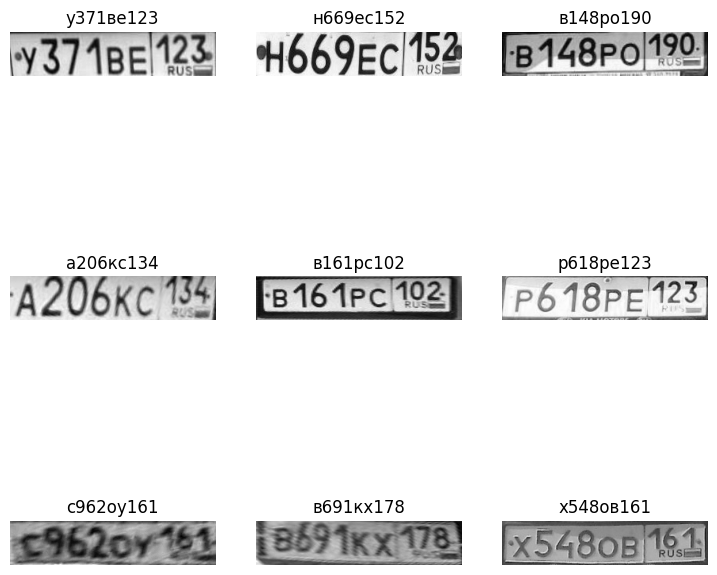

In [ ]:
sample = train_data.sample(9, random_state=2345)
plot_samples(sample['image'], sample['number']);

In [ ]:
def plot_progress(lrs, train_losses, train_cers, train_accs, val_losses, val_cers, val_accs):
    clear_output(True)

    f, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4)
    f.set_figheight(6)
    f.set_figwidth(20)

    ax1.plot(train_losses, label='train loss')
    ax1.plot(val_losses, label='val loss')
    ax1.plot(np.zeros_like(train_losses), '--', label='zero')
    ax1.set_title('Loss')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Batch number')
    ax1.legend()

    ax2.plot(train_accs, label='train CER')
    ax2.plot(val_cers, label='val CER')
    ax2.plot(np.ones_like(train_accs), '--', label='100% accuracy')
    ax2.set_title('Char error rate')
    ax2.set_ylabel('CER')
    ax2.set_xlabel('Batch number')
    ax2.legend()

    ax3.plot(train_accs, label='train accuracy')
    ax3.plot(val_accs, label='val accuracy')
    ax3.plot(np.ones_like(train_accs), '--', label='100% accuracy')
    ax3.set_title('Accuracy')
    ax3.set_ylabel('Accuracy')
    ax3.set_xlabel('Batch number')
    ax3.legend()

    ax4.plot(lrs, label='learning rate')
    ax4.set_title('Learing rate')
    ax4.set_xlabel('Batch number')
    ax4.legend()

    plt.show()

In [ ]:
letters = set(''.join(train_data.number))
n_letters = len(letters)

letter_index_map = {l: i for i, l in enumerate(letters)}
index_letter_map = {i: l for l, i in letter_index_map.items()}

In [ ]:
index_letter_map

{0: 'р',
 1: '3',
 2: '5',
 3: '0',
 4: '1',
 5: 'т',
 6: '6',
 7: 'н',
 8: '9',
 9: 'с',
 10: '2',
 11: 'х',
 12: '4',
 13: 'у',
 14: 'в',
 15: 'м',
 16: 'е',
 17: '7',
 18: '8',
 19: 'к',
 20: 'а',
 21: 'о'}

In [ ]:
class PlateNumberDataset(Dataset):

    def __init__(self, image_folder, images, labels, mode='fit'):
        self.image_folder = image_folder
        self.images = images
        self.labels = labels
        self.mode = mode
        self.norm = T.Normalize(MEAN, STD)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = read_image(os.path.join(self.image_folder, self.images[idx]))
        image = image.repeat(3, 1, 1)

        image = self.norm(image.float() / 255.)
        labels = self.transform_labels(self.labels[idx])

        return image, labels

    @staticmethod
    def transform_labels(label_text):
        return torch.tensor([letter_index_map[l] for l in label_text])

In [ ]:
resnet18

<function torchvision.models.resnet.resnet18(*, weights: Optional[torchvision.models.resnet.ResNet18_Weights] = None, progress: bool = True, **kwargs: Any) -> torchvision.models.resnet.ResNet>

In [ ]:
class PlateNumberReader(nn.Module):

    def __init__(self, pretrained=True):
        super(PlateNumberReader, self).__init__()
        self.resnet = nn.Sequential(*(list(resnet18(pretrained=pretrained).children())[:-2]))
        self.cnn = nn.Conv1d(in_channels=512, kernel_size=3, padding=1, out_channels=n_letters)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.resnet(x)
        x = x.mean(axis=2)
        x = self.relu(x)
        x = self.cnn(x)
        return x

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data.image, train_data.number, test_size=0.1,
)

train_dataset = PlateNumberDataset(image_folder=TRAIN_IMAGES_FODLER, images=X_train.values, labels=y_train.values)
val_dataset = PlateNumberDataset(image_folder=TRAIN_IMAGES_FODLER, images=X_val.values, labels=y_val.values, mode='predict')

train_sequence_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_sequence_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

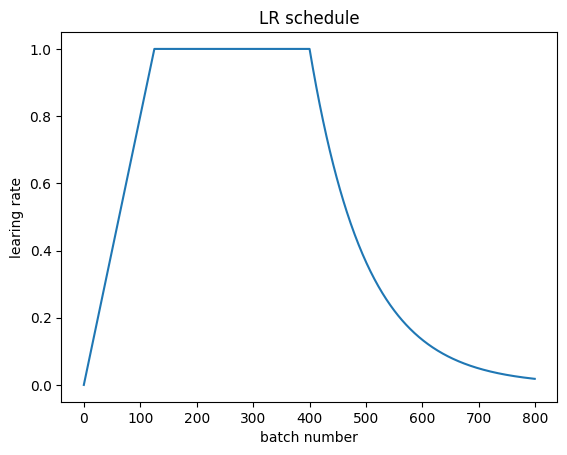

In [ ]:
def schedule(step_number, breaking_step1=125, breaking_step2=400):

    if step_number < breaking_step1:
        return step_number / breaking_step1
    elif step_number < breaking_step2:
        return 1
    else:
        return (0.99 ** (step_number - breaking_step2))


n_steps = 800
plt.plot(np.arange(n_steps), [schedule(step) for step in np.arange(n_steps)])
plt.title('LR schedule')
plt.ylabel('learing rate')
plt.xlabel('batch number');

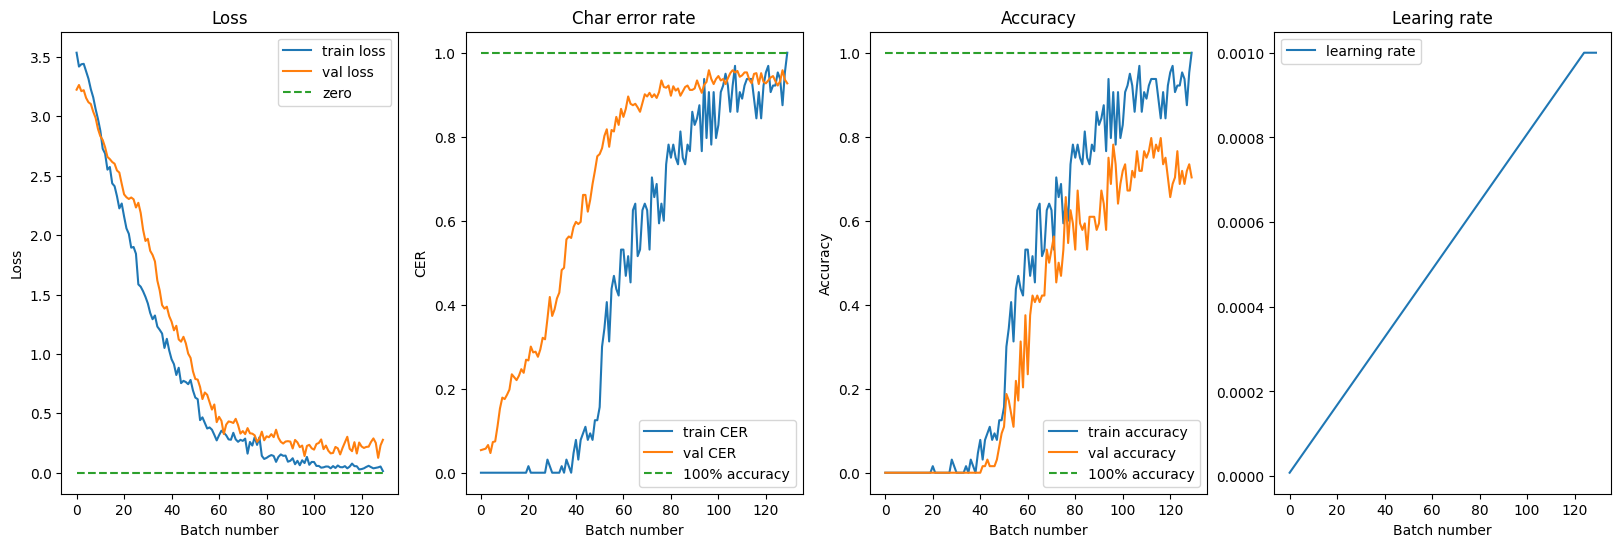

In [ ]:
model = PlateNumberReader()
model.to(DEVICE)

for i, param in enumerate(model.parameters()):
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)
loss_func = nn.CrossEntropyLoss()

n_epochs = 5

losses = []
accs = []
accs_agg = []

val_losses = []
val_accs = []
val_accs_agg = []

lrs = []

for i in range(n_epochs):
    for j, (x_train, y_train) in enumerate(train_sequence_dataloader):

        x_train = x_train.to(DEVICE)
        y_train = y_train.to(DEVICE)

        model.train()
        preds = model(x_train)
        train_loss = loss_func(preds, y_train)
        train_acc = (torch.argmax(preds, dim=1) == y_train).float().mean()
        train_acc_agg = (torch.argmax(preds, dim=1) == y_train).all(dim=1).float().mean()

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        scheduler.step()

        lrs.append(optimizer.param_groups[0]["lr"])
        model.eval()

        x_val, y_val = next(iter(val_sequence_dataloader))

        x_val = x_val.to(DEVICE)
        y_val = y_val.to(DEVICE)

        with torch.no_grad():
            val_preds = model(x_val)
            val_loss = loss_func(val_preds, y_val)
            val_acc = (torch.argmax(val_preds, dim=1) == y_val).float().mean()
            val_acc_agg = (torch.argmax(val_preds, dim=1) == y_val).all(dim=1).float().mean()

            losses.append(train_loss.item())
            accs.append(train_acc.item())
            accs_agg.append(train_acc_agg.item())

            val_losses.append(val_loss.item())
            val_accs.append(val_acc.item())
            val_accs_agg.append(val_acc_agg.item())

            plot_progress(lrs, losses, accs, accs_agg, val_losses, val_accs, val_accs_agg)


### Аугментации данных

In [ ]:
image_augmentations = T.Compose([
    T.RandomAffine(5, shear=3),
    T.RandomPerspective(distortion_scale=0.12, p=0.6),
    T.RandomApply([T.ColorJitter(brightness=0.3, contrast=0.3)], p=0.6),
    T.RandomAutocontrast(p=0.6),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.6),
])


In [ ]:
def plot_samples_with_augs(images, labels, transform=None, nrows=3, ncols=3):

    f, axes = plt.subplots(nrows=nrows, ncols=nrows,)
    f.set_figheight(9)
    f.set_figwidth(9)

    for im_file, num, ax in zip(images, labels, axes.flatten()):
        im_path = os.path.join(TRAIN_IMAGES_FODLER, im_file)
        im = Image.open(im_path)

        if transform:
            im = transform(im)

        ax.imshow(im, cmap='gray')
        ax.set_title(num)
        ax.axis('off')

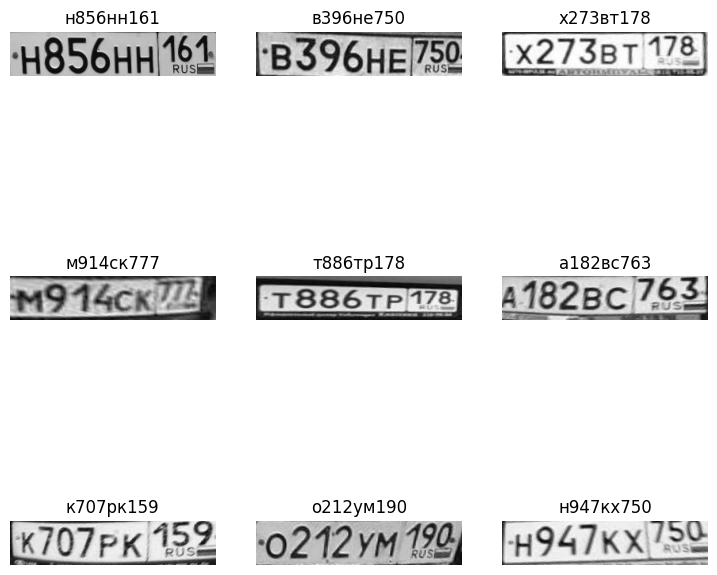

In [ ]:
sample = train_data.sample(9, random_state = 1)
plot_samples_with_augs(sample['image'], sample['number'], transform=None);

In [ ]:
class PlateNumberWithAugmentationsDataset(Dataset):

    def __init__(self, image_folder, images, labels, mode='fit'):
        self.image_folder = image_folder
        self.images = images
        self.labels = labels
        self.mode = mode
        self.norm = T.Normalize(MEAN, STD)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = read_image(os.path.join(self.image_folder, self.images[idx]))
        image = image.repeat(3, 1, 1)

        if self.mode =='fit':
            image = image_augmentations(image)

        image = self.norm(image.float() / 255.)
        labels = self.transform_labels(self.labels[idx])

        return image, labels

    @staticmethod
    def transform_labels(label_text):
        return torch.tensor([letter_index_map[l] for l in label_text])

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data.image, train_data.number, test_size=0.1,
)

train_dataset = PlateNumberWithAugmentationsDataset(image_folder=TRAIN_IMAGES_FODLER, images=X_train.values, labels=y_train.values)
val_dataset = PlateNumberWithAugmentationsDataset(image_folder=TRAIN_IMAGES_FODLER, images=X_val.values, labels=y_val.values, mode='predict')

train_sequence_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_sequence_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

In [ ]:
next(iter(train_sequence_dataloader))[0].shape

torch.Size([64, 3, 56, 260])

In [ ]:
def schedule(step_number, breaking_step1=125, breaking_step2=400):

    if step_number < breaking_step1:
        return step_number / breaking_step1
    elif step_number < breaking_step2:
        return 1
    else:
        return (0.99 ** (step_number - breaking_step2))

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

class PlateNumberReader(nn.Module):

    def __init__(self, pretrained=True):
        super(PlateNumberReader, self).__init__()

        self.resnet = nn.Sequential(*(list(resnet18(pretrained=pretrained).children())[:-2]))

        dropout = 0.33

        self.proj = nn.Linear(512, 256)
        self.ln_in = nn.LayerNorm(256)
        self.drop_in = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
            dropout=dropout,
        )

        self.ln_out = nn.LayerNorm(512)
        self.drop_out = nn.Dropout(0.33)

        self.fc = nn.Linear(512, n_letters)

    def forward(self, x):
        x = self.resnet(x)
        x = x.mean(dim=2)

        x = x.permute(0, 2, 1)
        x = self.proj(x)

        x = self.ln_in(x)
        x = self.drop_in(x)

        x, _ = self.lstm(x)

        x = self.ln_out(x)
        x = self.drop_out(x)

        x = self.fc(x)
        x = x.permute(0, 2, 1)
        return x



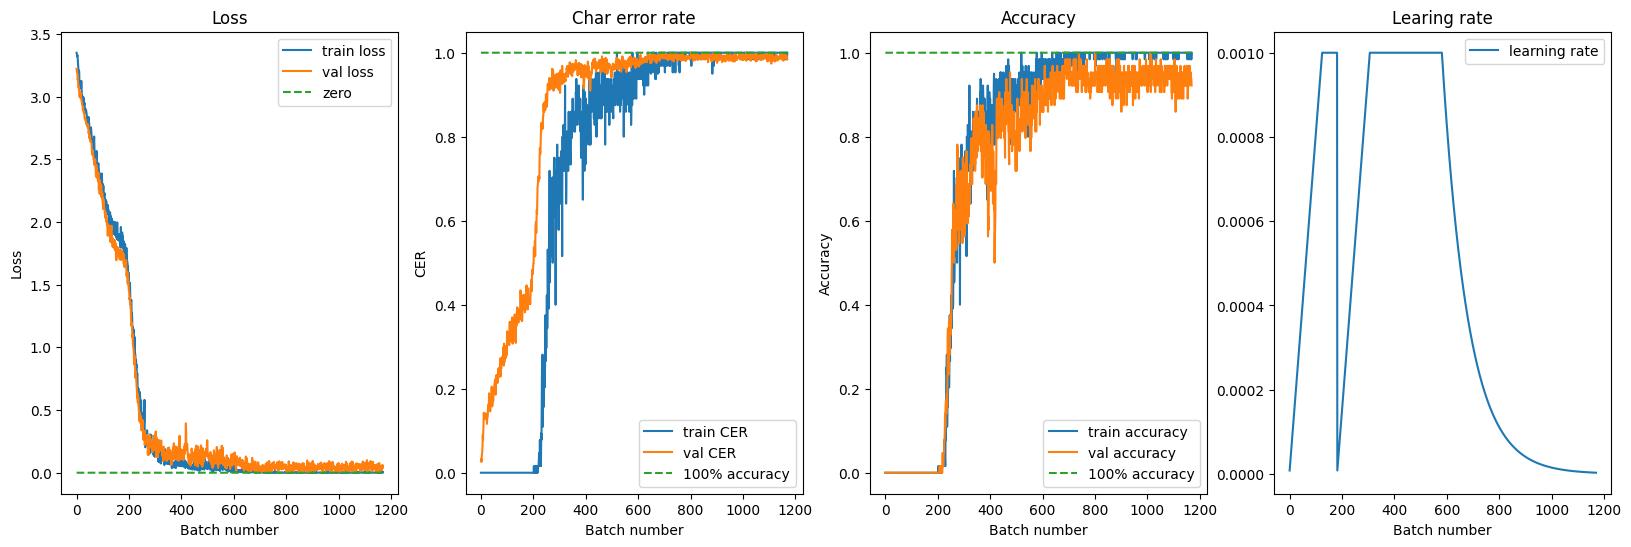

In [ ]:
model = PlateNumberReader()
model.to(DEVICE)

for i, param in enumerate(model.resnet.parameters()):
    param.requires_grad = False

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)
loss_func = nn.CrossEntropyLoss()

n_epochs = 45

losses = []
accs = []
accs_agg = []

val_losses = []
val_accs = []
val_accs_agg = []

lrs = []


for i in range(n_epochs):
    print(f'Current iter: {i+1}')
    if i == 7:
        for param in model.resnet.parameters():
            param.requires_grad = True

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, schedule2)
        loss_func = nn.CrossEntropyLoss()
    for j, (x_train, y_train) in enumerate(train_sequence_dataloader):

        x_train = x_train.to(DEVICE)
        y_train = y_train.to(DEVICE).float().unsqueeze(1)

        model.train()
        preds = model(x_train)
        train_loss = loss_func(preds, y_train)
        train_acc = (torch.argmax(preds, dim=1) == y_train).float().mean()
        train_acc_agg = (torch.argmax(preds, dim=1) == y_train).all(dim=1).float().mean()

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        scheduler.step()

        lrs.append(optimizer.param_groups[0]["lr"])
        model.eval()

        x_val, y_val = next(iter(val_sequence_dataloader))

        x_val = x_val.to(DEVICE)
        y_val = y_val = y_val.to(DEVICE).float().unsqueeze(1)

        with torch.no_grad():
            val_preds = model(x_val)
            val_loss = loss_func(val_preds, y_val)
            val_acc = (torch.argmax(val_preds, dim=1) == y_val).float().mean()
            val_acc_agg = (torch.argmax(val_preds, dim=1) == y_val).all(dim=1).float().mean()

            losses.append(train_loss.item())
            accs.append(train_acc.item())
            accs_agg.append(train_acc_agg.item())

            val_losses.append(val_loss.item())
            val_accs.append(val_acc.item())
            val_accs_agg.append(val_acc_agg.item())

            plot_progress(lrs, losses, accs, accs_agg, val_losses, val_accs, val_accs_agg)

In [ ]:
test_data = pd.read_csv(TEST_FILE)
class TestPlateNumberDataset(Dataset):

    def __init__(self, image_folder, images):
        self.image_folder = image_folder
        self.images = images
        self.norm = T.Normalize(MEAN, STD)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = read_image(os.path.join(self.image_folder, self.images[idx]))
        image = image.repeat(3, 1, 1)
        image = self.norm(image.float() / 255.)

        return self.images[idx], image

def decode_preds(lst):
    res = ''
    for i in lst:
        res += index_letter_map[i]
    return res

test_dataset = TestPlateNumberDataset(image_folder=TEST_IMAGES_FODLER, images=test_data.image.values)

test_sequence_dataloader = DataLoader(test_dataset, batch_size=64)
ans_df = pd.DataFrame()
results = []
for imgs, x_test in test_sequence_dataloader:
    x_test = x_test.to(DEVICE)
    preds = model(x_test).argmax(dim=1).cpu().numpy()
    for i in range(len(imgs)):
        results.append([imgs[i], preds[i]])

In [ ]:
pd.DataFrame(results).to_csv('solution.csv', header=['image', 'plate_number'])